# The Market Runs on Volume Time ⏱️
### Are fat tails just normal returns measured on the wrong clock?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

A busy day is not one day — it is many quiet days' worth of trading squeezed into one session.
Fifty years ago Peter Clark proposed that if you measured time by *trading volume* rather than
by the calendar, the wild, fat-tailed behaviour of daily prices would melt into a plain bell
curve. We tested it on twenty years of the S&P 500 and the Nasdaq.

> 📓 **This is the plain-language layer.** The bootstrap intervals, the forecast race
> and the cost sweep are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it,
> from frozen data tapes shipped inside the `arch` Python package.

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
plt.rcParams["figure.dpi"] = 80
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
pd.set_option("display.width", 160)
from volclock import data, strategy as st
tapes = data.load_all()
print(f"as-of {data.AS_OF} | source: {data.SOURCE}")
for n, t in tapes.items():
    print(f"  {data.TAPE_LABELS[n]:32s} {t.index[0].date()} -> {t.index[-1].date()}  "
          f"{len(t):,} sessions  fingerprint {data.fingerprint(t)}")

as-of 2018-12-31 | source: arch (bundled data, via quantlab.bundled.load_arch)
  S&P 500 (price index)            1999-01-04 -> 2018-12-31  5,031 sessions  fingerprint 2da6b3800e6c
  Nasdaq Composite (price index)   1999-01-04 -> 2018-12-31  5,031 sessions  fingerprint 2a173ef678c8


## The answer first 🎯

| Question | Answer |
|---|---|
| Do volume and volatility move together? | Yes — strongly, and on the same day. |
| Does the volume clock turn daily returns into a bell curve? | No. It trims the tails a little. |
| What does explain most of the fat tails? | Volatility *clustering* — calm and stormy spells. |
| Can you use yesterday's volume to forecast tomorrow? | Not beyond what the price range already tells you. |

**Signal: Weak · Tradability: Mirage.** Volume and volatility move together, but volume time is a weak clock: dividing by same-day volume removes 14%–21% of the excess kurtosis of daily index returns and leaves them far from normal, and by the time anyone can read the clock it is spent — lagged volume adds nothing significant to a range-based HAR forecast and nothing to a vol-targeting overlay.

## 1 · The claim

Daily stock-market returns have **fat tails**: crashes and melt-ups happen far more often than a
bell curve would allow. The usual reaction is to reach for a fatter-tailed distribution. Clark
(1973) proposed something more elegant: the bell curve is fine, **the clock is wrong**. Prices
move one small random step per trade, so a day with three times the usual trading packs three
days of steps into one session. Mix quiet days and frantic days together and you get fat tails
— even though, trade by trade, everything is perfectly normal.

Ané & Geman (2000) pushed the idea further and reported near-normal returns once time was
counted in trades. The believer's version: **"divide each day's move by the square root of how
much trading happened, and the fat tails disappear."**

## 2 · So what?

If it were true, risk management would get much simpler: measure the volume clock and the
bell-curve arithmetic works again. And a trader who could see the clock ticking fast would know
that big moves are coming — if, and it is a big *if*, the clock can be read before the moves
happen.

## 3 · How we'd know

Written down before the real data were touched:

1. **Measure.** Divide each day's return by the square root of that day's volume (relative to the
   volume of the previous three months, so the 2000s volume boom does not swamp everything). If
   Clark is right, most of the excess "tail-heaviness" (the *kurtosis*) should vanish. Bar: at
   least a quarter of it, with a confidence interval above zero, on **both** indices.
2. **Compare.** Two yardsticks: dividing by the day's own high-low range (the best case — it *is*
   the day's volatility) and by a standard forecasting model that only uses the past (GARCH).
3. **The catch.** Today's volume is only known after today's close. So: does **yesterday's**
   volume help forecast **tomorrow's** turbulence, and does a strategy built on that forecast earn
   more after costs? If not, it is a mirage.

## 4 · The teardown

### 4.1 The raw volume number is useless as it stands

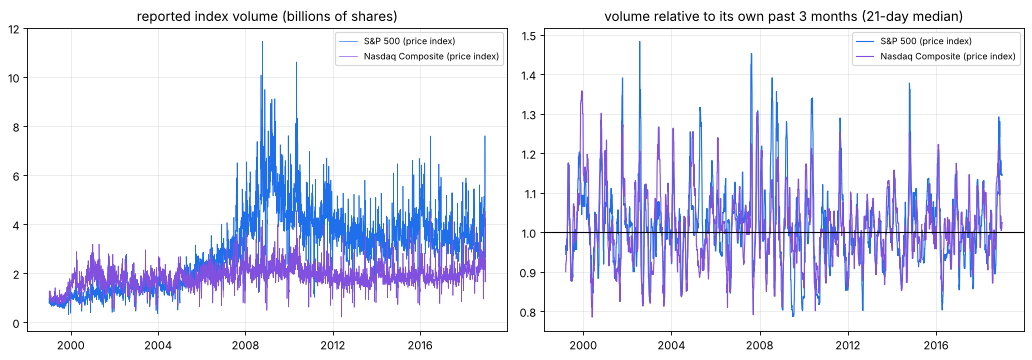

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for (n, t), c in zip(tapes.items(), ("#1f6feb", "#8250df")):
    axes[0].plot(t.index, t["volume"] / 1e9, lw=0.6, color=c, label=data.TAPE_LABELS[n])
    rv = st.relative_volume(t["volume"])
    axes[1].plot(rv.index, rv.rolling(21).median(), lw=1.0, color=c, label=data.TAPE_LABELS[n])
axes[0].set_title("reported index volume (billions of shares)")
axes[1].set_title("volume relative to its own past 3 months (21-day median)")
axes[1].axhline(1, color="k", lw=1)
for a in axes:
    a.legend(fontsize=8)
plt.tight_layout(); plt.show()

On the left, S&P volume quadruples between 1999 and 2009 for reasons that have little to do with
how much news arrived. On the right, the same series measured against its own recent past —
the version of the clock used throughout.

### 4.2 Do volume and turbulence move together?

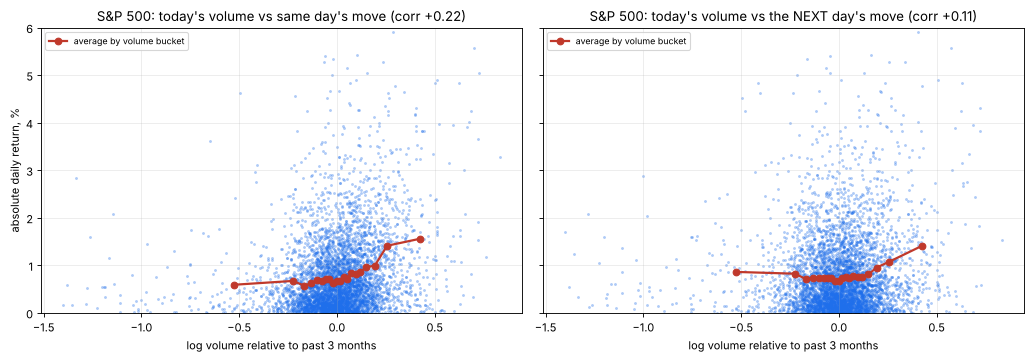

In [3]:
t = tapes["sp500"]
r = st.log_returns(t["close"])
lv = np.log(st.relative_volume(t["volume"]))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
for ax, k, title in ((axes[0], 0, "same day"), (axes[1], 1, "the NEXT day")):
    d = pd.concat([lv.rename("v"), (r.abs() * 100).shift(-k).rename("a")], axis=1).dropna()
    ax.scatter(d["v"], d["a"], s=3, alpha=0.25, color="#1f6feb")
    bins = pd.qcut(d["v"], 20)
    g = d.groupby(bins, observed=True).mean()
    ax.plot(g["v"], g["a"], "o-", color="#c0392b", lw=2, label="average by volume bucket")
    ax.set_title(f"S&P 500: today's volume vs {title}'s move (corr {d['v'].corr(d['a']):+.2f})")
    ax.set_xlabel("log volume relative to past 3 months"); ax.legend(fontsize=8)
axes[0].set_ylabel("absolute daily return, %")
axes[1].set_ylim(0, 6)
plt.tight_layout(); plt.show()

On the same day, high-volume sessions are clearly the turbulent ones. One day later the red line
is much flatter. That gap — strong today, weak tomorrow — is the whole study in one picture.

### 4.3 Does the volume clock make the bell curve appear?

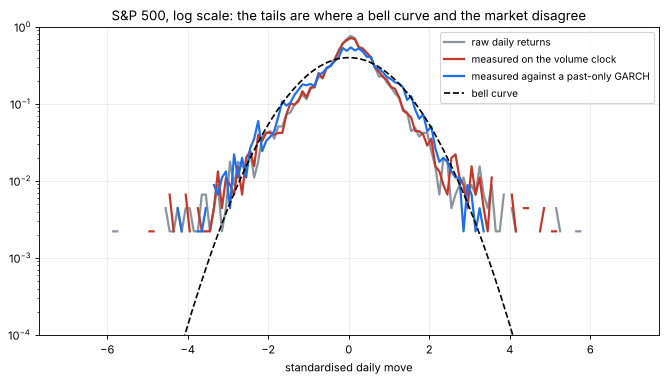

In [4]:
P = st.clock_panel(tapes["sp500"])
fig, ax = plt.subplots(figsize=(10, 5))
grid = np.linspace(-7, 7, 141)
for c, col, lab in (("raw", "#8b949e", "raw daily returns"),
                    ("volume", "#c0392b", "measured on the volume clock"),
                    ("garch", "#1f6feb", "measured against a past-only GARCH")):
    h, e = np.histogram(P[c], bins=grid, density=True)
    ax.semilogy(0.5 * (e[1:] + e[:-1]), np.where(h > 0, h, np.nan), lw=2, color=col, label=lab)
ax.semilogy(grid, np.exp(-grid ** 2 / 2) / np.sqrt(2 * np.pi), "k--", lw=1.5, label="bell curve")
ax.set_ylim(1e-4, 1); ax.set_xlabel("standardised daily move"); ax.legend(fontsize=9)
ax.set_title("S&P 500, log scale: the tails are where a bell curve and the market disagree")
plt.show()

On a log scale, a bell curve is the dashed parabola. Raw returns (grey) spread far beyond it. The
volume clock (red) barely pulls them in; a model that simply remembers whether the market has been
calm or stormy lately (blue) does much more.

> 🔬 **For the quants.** The blue line uses only *past* data — it is a forecast. The red
> line uses *same-day* volume, information the blue line does not have, and still does worse.

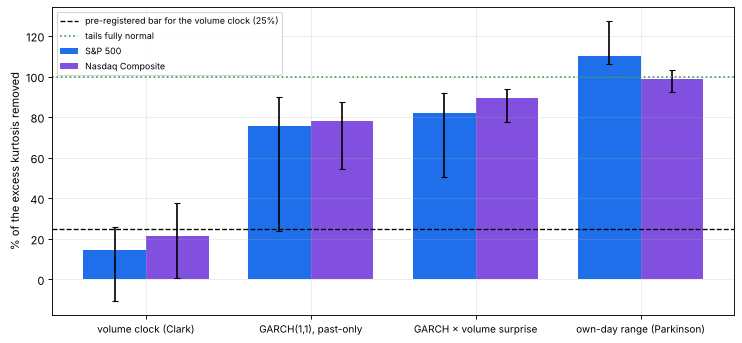

,tape,clock,share,lo,hi
0,S&P 500,volume clock (Clark),0.1430,-0.1070,0.2590
1,S&P 500,"GARCH(1,1), past-only",0.7570,0.2400,0.9000
2,S&P 500,GARCH × volume surprise,0.8230,0.5070,0.9190
3,S&P 500,own-day range (Parkinson),1.1000,1.0620,1.2740
4,Nasdaq Composite,volume clock (Clark),0.2130,0.0080,0.3780
5,Nasdaq Composite,"GARCH(1,1), past-only",0.7800,0.5420,0.8750
6,Nasdaq Composite,GARCH × volume surprise,0.8940,0.7780,0.9400
7,Nasdaq Composite,own-day range (Parkinson),0.9870,0.9240,1.0310


In [5]:
rows = []
for n, t in tapes.items():
    K = st.kurtosis_removed(st.clock_panel(t), n_boot=300)
    for c in ("volume", "garch", "garch_volume", "range"):
        rows.append({"tape": data.TAPE_LABELS[n].split(" (")[0], "clock": st.CLOCK_LABELS[c],
                     "share": K.loc[c, "share_removed"], "lo": K.loc[c, "share_ci_lo"],
                     "hi": K.loc[c, "share_ci_hi"]})
d = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(11, 5))
clocks = d["clock"].unique()
x = np.arange(len(clocks))
for i, (tp, col) in enumerate(zip(d["tape"].unique(), ("#1f6feb", "#8250df"))):
    s = d[d["tape"] == tp].set_index("clock").loc[clocks]
    ax.bar(x + (i - 0.5) * 0.38, s["share"] * 100, 0.38, color=col, label=tp,
           yerr=[(s["share"] - s["lo"]) * 100, (s["hi"] - s["share"]) * 100], capsize=3)
ax.axhline(25, color="k", ls="--", lw=1.2, label="pre-registered bar for the volume clock (25%)")
ax.axhline(100, color="#2ea44f", ls=":", lw=1.5, label="tails fully normal")
ax.set_xticks(x); ax.set_xticklabels(clocks, fontsize=9)
ax.set_ylabel("% of the excess kurtosis removed"); ax.legend(fontsize=8)
plt.show()
d.round(3)

The volume clock removes a sliver of the tail-heaviness — under the bar we set in advance. The day's
own range removes all of it, but that is cheating on purpose: it *is* the day's turbulence,
measured. The honest comparison is the past-only model, which removes three-quarters, and adding
same-day volume *on top of it* helps a little more.

## 5 · The verdict

**Signal: Weak.** Divide each day's return by the square root of that day's volume (relative to its own past-only 63-day median) and the excess kurtosis moves — S&P 500 from **9.2 to 7.9**, 14% of it removed (block-bootstrap 95% CI -12% to 26%); Nasdaq from **6.2 to 4.9**, 21% of it removed (block-bootstrap 95% CI 1% to 38%). The correlation of volume with the absolute return is S&P 500 +0.22 on the same day (Newey–West t 8.3) against +0.11 with the next day; Nasdaq +0.19 on the same day (Newey–West t 8.3) against +0.05 with the next day. The link is unmistakable but the clock is a weak one: on its own it misses the pre-registered bar (at least 25% of the excess kurtosis removed, bootstrap CI above zero) on both tapes. Nor does it make returns Gaussian: Jarque–Bera still rejects normality in volume time on every tape. The benchmarks bracket it: the day's own range (an upper bound, since it *is* that day's volatility) removes S&P 500 110%; Nasdaq 99%, a past-only GARCH removes S&P 500 76%; Nasdaq 78%, and GARCH times same-day volume *surprise* removes S&P 500 82%; Nasdaq 89% — a further reduction over GARCH alone whose bootstrap CI excludes zero on Nasdaq. Most of the fat tail is volatility clustering, which a past-only model already sees; the volume clock adds a same-day sliver on top.

**Tradability: Mirage.** The clock is read at the close of the day it explains, so the usable question is whether **yesterday's** volume sharpens **tomorrow's** variance forecast beyond a range-based log-HAR. Out of sample (monthly refits, expanding window), adding lagged relative volume moves next-day QLIKE on squared returns with a Diebold–Mariano t of S&P 500 **+0.95** (p 0.34); Nasdaq **+0.12** (p 0.90) — negative would favour volume. Against the range-variance target the DM t is S&P 500 -0.10; Nasdaq -1.77. Built into a 15%-target vol overlay traded one session after the forecast, at 2 bp one-way, the volume-aware overlay's Sharpe minus the plain HAR overlay's is S&P 500 **+0.001** (bootstrap p 0.80); Nasdaq **+0.000** (bootstrap p 0.95). (The range-based HAR is itself the better forecaster — against GARCH its QLIKE DM t is S&P 500 -5.2; Nasdaq -5.4 — so the benchmark being beaten is not a straw man.) The impossible version — sizing today's position by today's volume, which nobody has until after the close — moves the gross Sharpe of a zero-lag HAR overlay from S&P 500 0.37 to 0.47; Nasdaq 0.52 to 0.64: whatever the clock is worth sits on the wrong side of the close.

## 6 · Could you trade it?

The tradable version: a "volatility-targeting" strategy that holds more of the index when the
forecast says calm and less when it says storm. We build it twice — with and without yesterday's
volume in the forecast — and trade one day late, as anyone using end-of-day volume would have to.

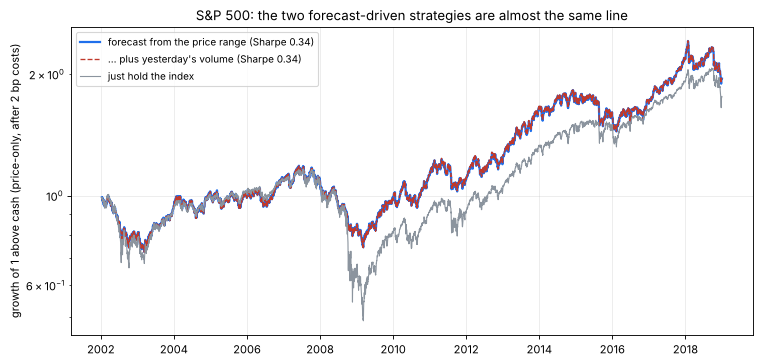

In [6]:
rf = data.load_daily_rf(tapes["sp500"].index)
fc = st.forecast_race(tapes["sp500"])
r_s = tapes["sp500"]["close"].pct_change()
fig, ax = plt.subplots(figsize=(11, 5))
for m, col, lab in (("har", "#1f6feb", "forecast from the price range"),
                    ("harx", "#c0392b", "... plus yesterday's volume")):
    ov = st.overlay(r_s, fc[f"{m}_r2"], rf, cost_bps=2.0)
    ax.plot((1 + ov["net"]).cumprod(), lw=2 if m == "har" else 1.2, color=col,
            ls="-" if m == "har" else "--", label=f"{lab} (Sharpe {st.sharpe(ov['net']):.2f})")
ax.plot((1 + ov["bh"]).cumprod(), color="#8b949e", lw=1, label="just hold the index")
ax.set_yscale("log"); ax.set_ylabel("growth of 1 above cash (price-only, after 2 bp costs)")
ax.set_title("S&P 500: the two forecast-driven strategies are almost the same line")
ax.legend(fontsize=9); plt.show()

The two lines sit on top of each other. Volatility targeting itself does something — it smooths the
ride compared with holding the index — but yesterday's volume adds nothing to it, because by the
next morning the price range has already told the forecast what the volume knew.

## 7 · Going further 🚪

- **A better clock.** Index volume is a sum of share counts across hundreds of stocks; Ané & Geman
  counted *trades* on single stocks, intraday. A trade-count or dollar-volume clock on futures or
  single names is the natural fork.
- **Unexpected volume.** The part of today's volume that a model did not expect is where the
  information lives; §3 of the quants notebook shows it helps on top of GARCH on the same day.
- **Intraday.** The theory is about ticks, not days. A study on intraday bars could test the
  clock where it was meant to run.
- **Fork it.** Everything here runs offline from tapes frozen inside the `arch` package — swap in
  your own clock in `volclock/strategy.py` and rerun `examples/verify.py`.